<a href="https://colab.research.google.com/github/lcn781/M10---Descritiva-II/blob/main/Profissa%CC%83o_Cientista_de_Dados_M10_Pratique_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 10 tarefa 03
Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Construa um gráfico de barras para avaliar a distribuição das variáveis qualitativas no tempo. Você acha que houve alguma alteração importante a ser investigada?

2) Para cada variável qualitativa, construa um gráfico mostrando as médias de cada nível da variável no tempo e avalie a estabilidade. Houve alguma alteração importante? Você acha que se pode utilizar essas variáveis em uma modelagem?

# RESPOSTA

A variável 'educacao' foi a que mais sofreu alteração ao longo do tempo, com um aumento significativo a partir de 09/2015.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sample_data
import sklearn
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('previsao_de_renda.csv')
df.head()

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


Qualitative columns identified: ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'mau']


<Figure size 1200x600 with 0 Axes>

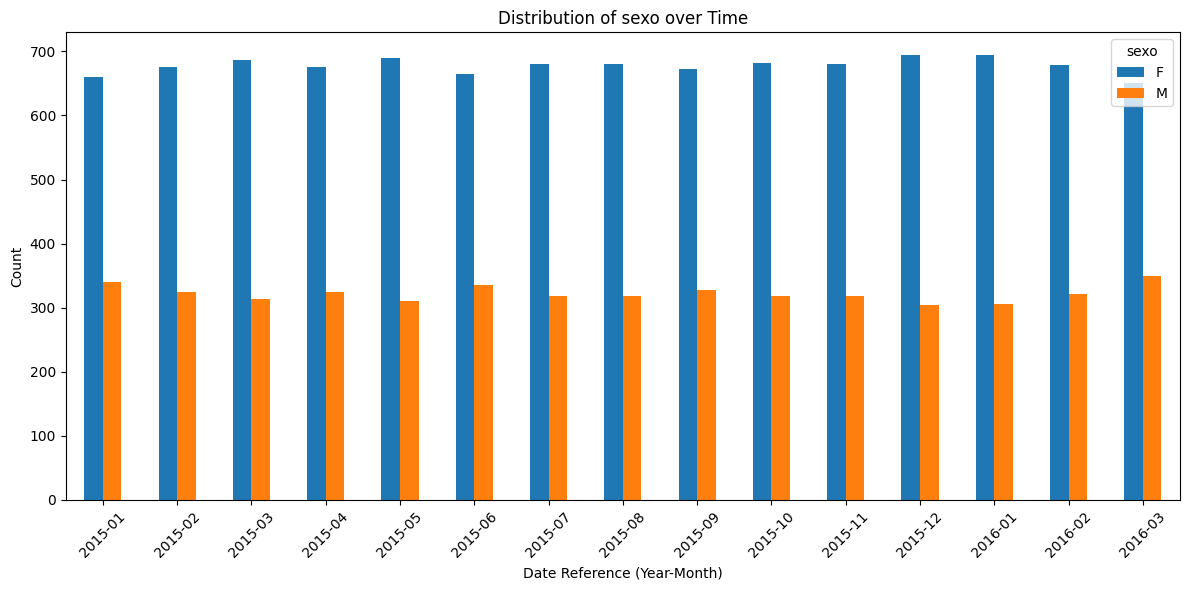

<Figure size 1200x600 with 0 Axes>

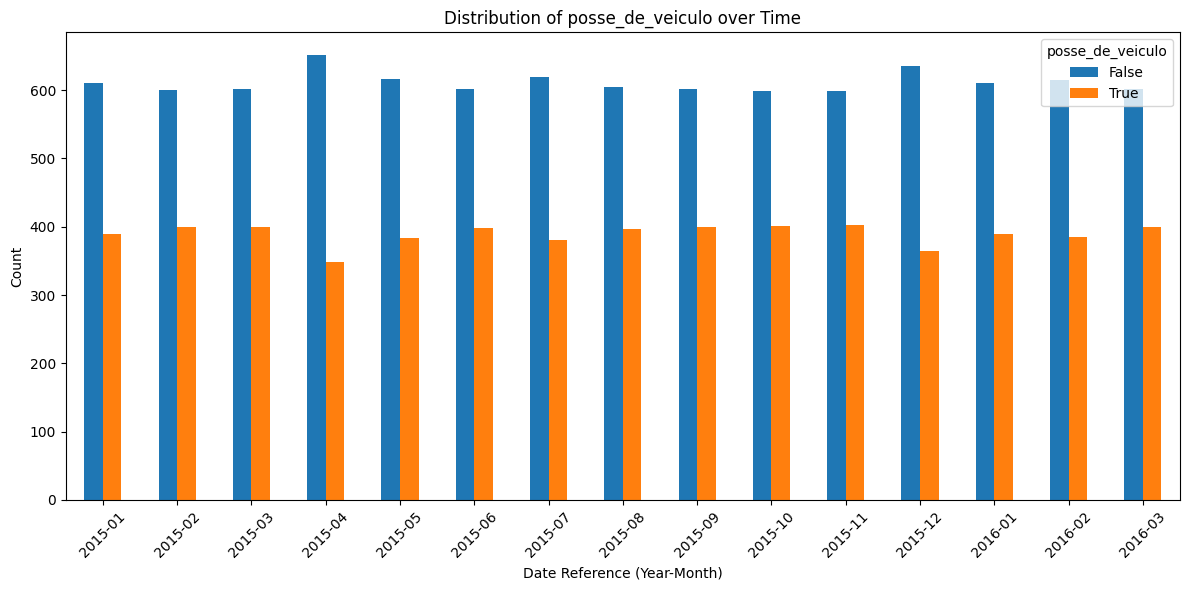

<Figure size 1200x600 with 0 Axes>

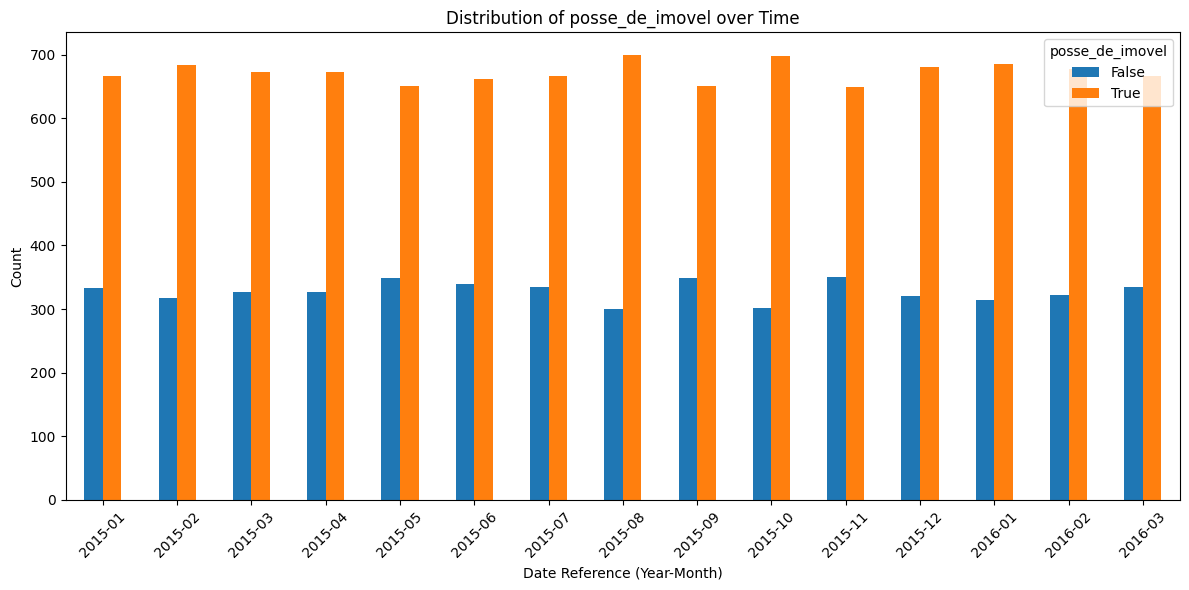

<Figure size 1200x600 with 0 Axes>

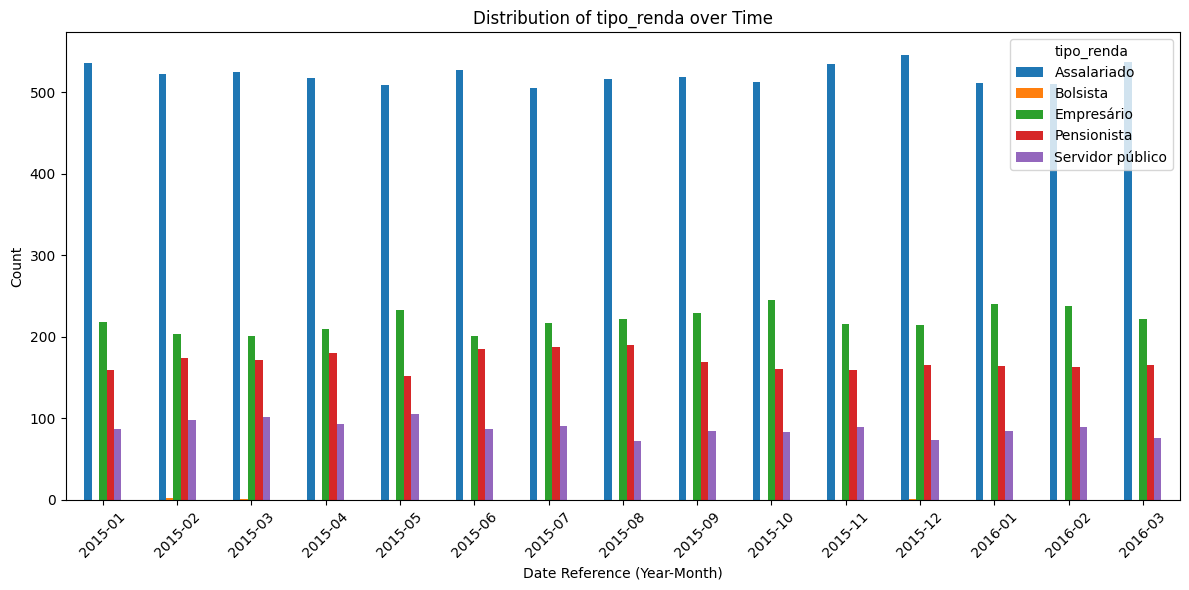

<Figure size 1200x600 with 0 Axes>

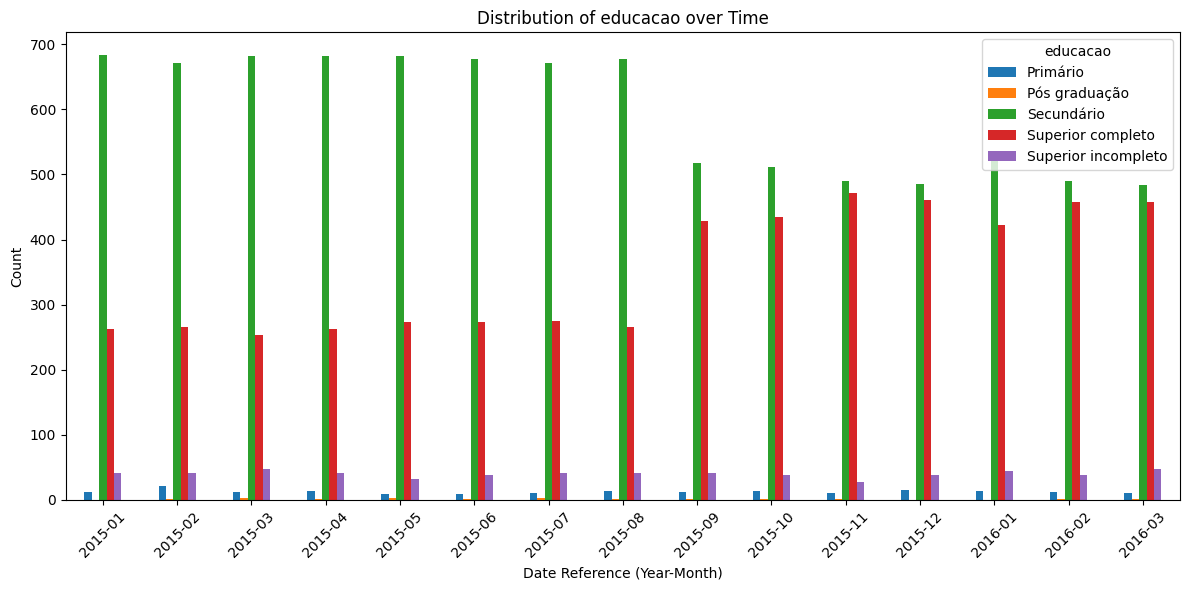

<Figure size 1200x600 with 0 Axes>

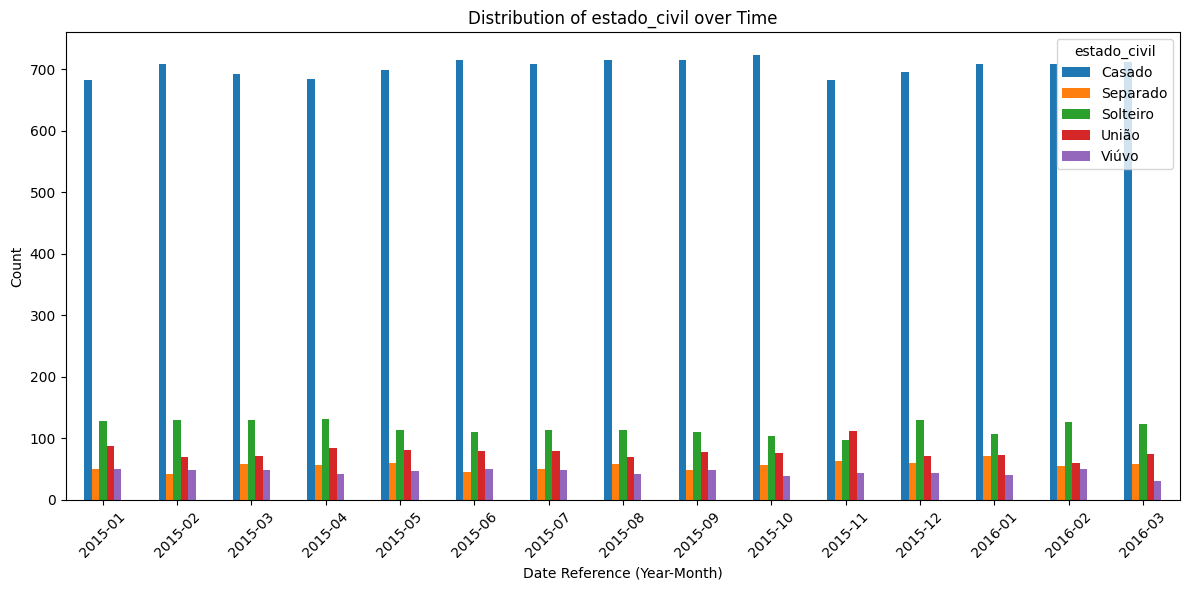

<Figure size 1200x600 with 0 Axes>

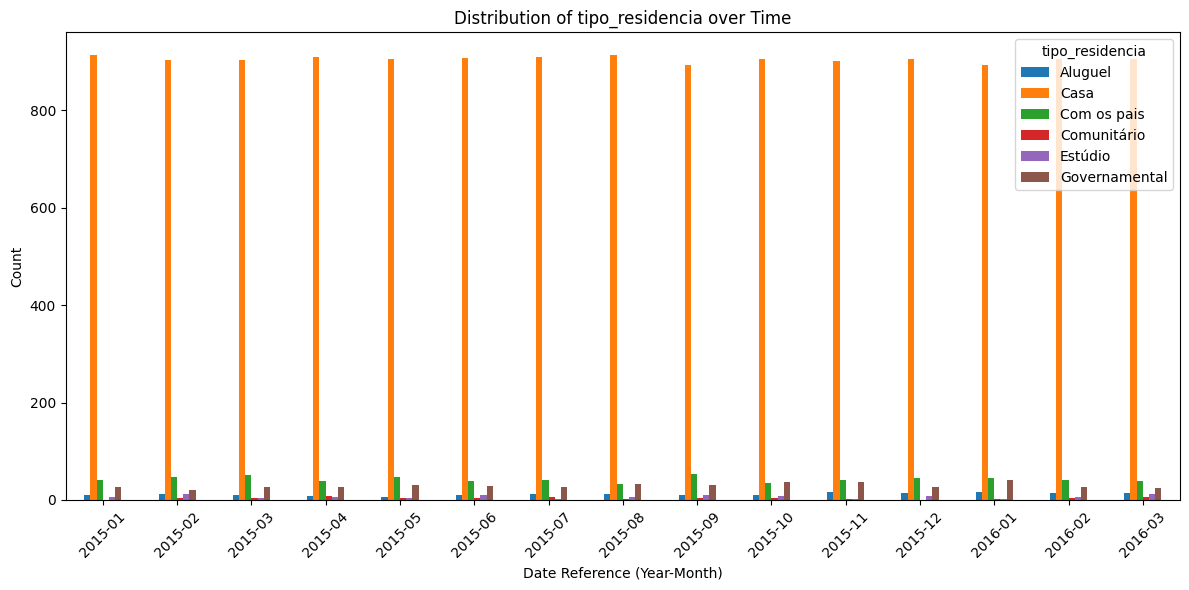

<Figure size 1200x600 with 0 Axes>

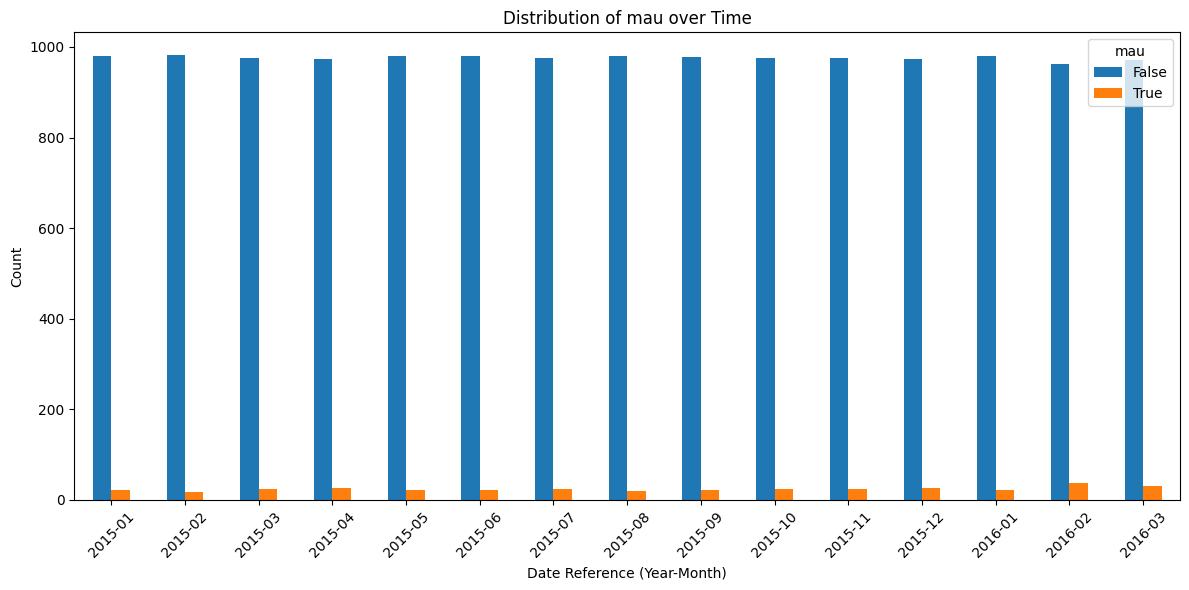

In [8]:
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Identify qualitative variables
# These are typically 'object' (string) or 'bool' (boolean) types.
qualitative_cols = df.select_dtypes(include=['object', 'bool']).columns

print("Qualitative columns identified:", list(qualitative_cols))

# Iterate through qualitative variables and create bar plots
for col in qualitative_cols:
    plt.figure(figsize=(12, 6))
    # Group by data_ref and the qualitative column, then count occurrences
    # Use unstack to make the qualitative column levels as columns for plotting
    plot_data = df.groupby(['data_ref', col]).size().unstack(fill_value=0)
    # Format the index to display only month and year
    plot_data.index = plot_data.index.strftime('%Y-%m')
    plot_data.plot(kind='bar', stacked=False, figsize=(12,6))
    plt.title(f'Distribution of {col} over Time')
    plt.xlabel('Date Reference (Year-Month)')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title=col)
    plt.tight_layout()
    plt.show()

<Figure size 1400x700 with 0 Axes>

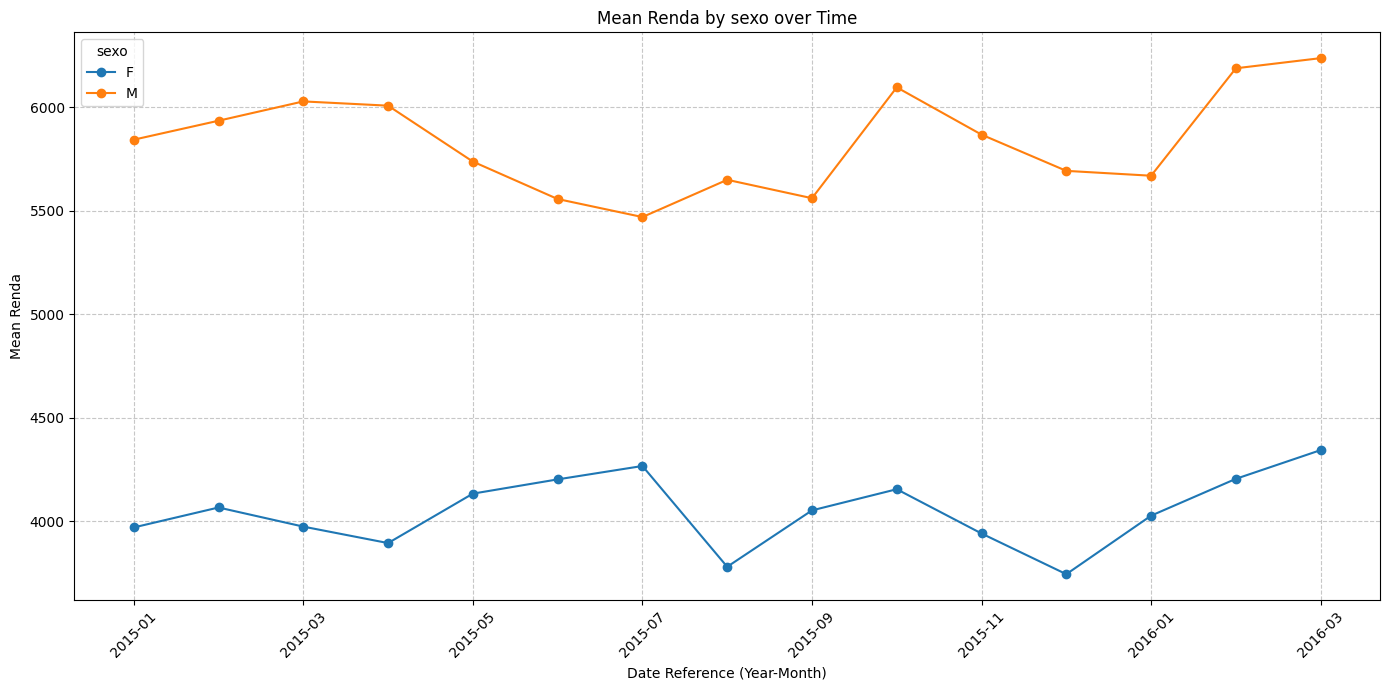

<Figure size 1400x700 with 0 Axes>

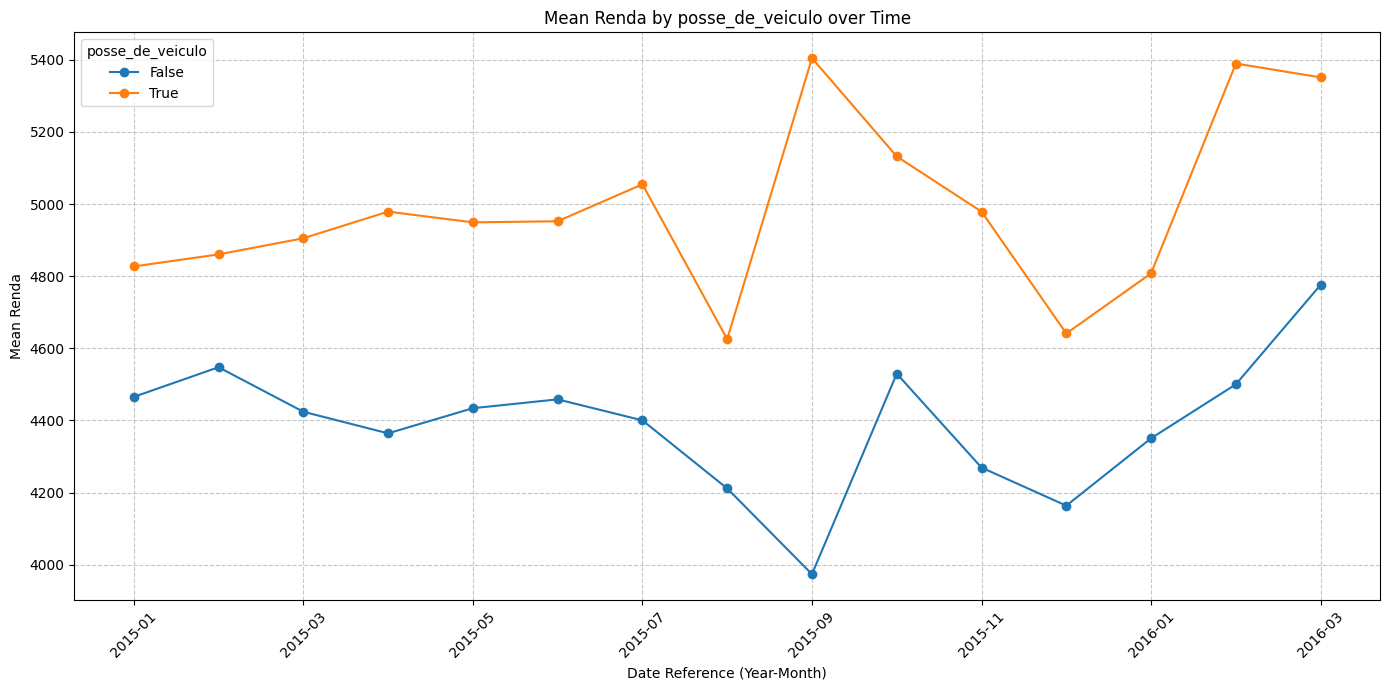

<Figure size 1400x700 with 0 Axes>

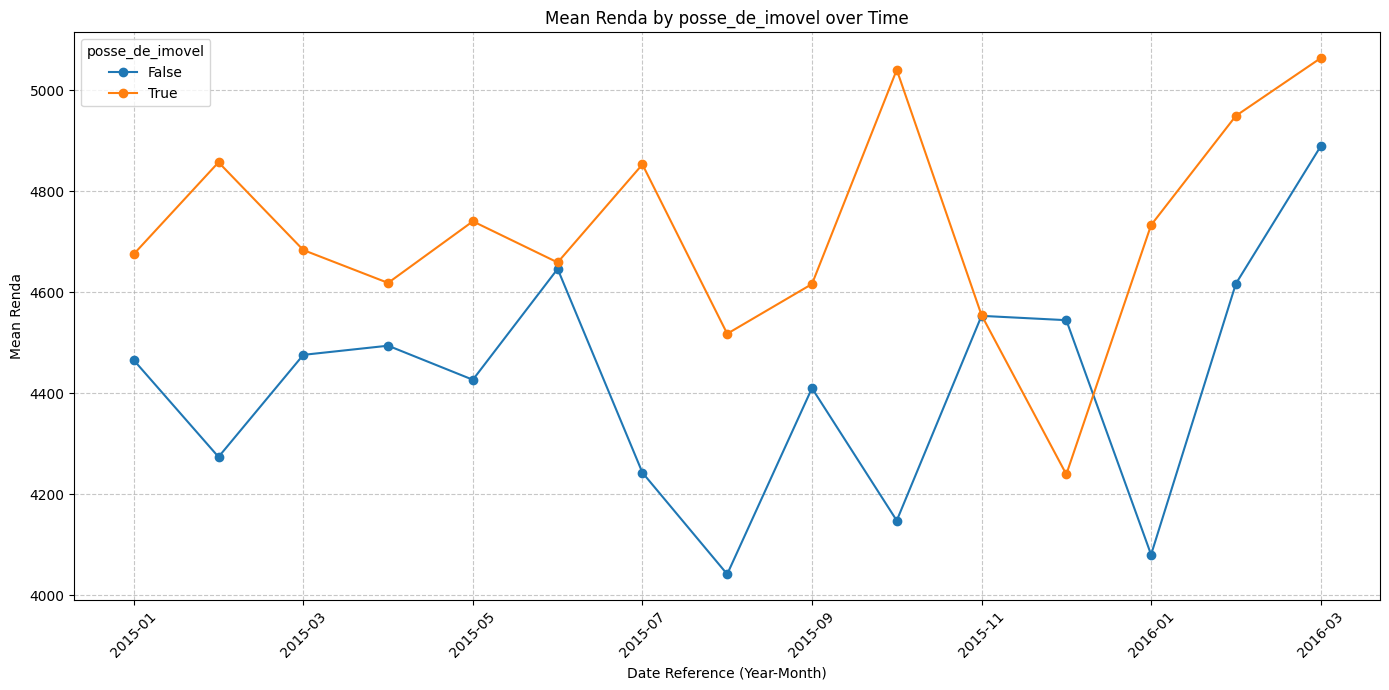

<Figure size 1400x700 with 0 Axes>

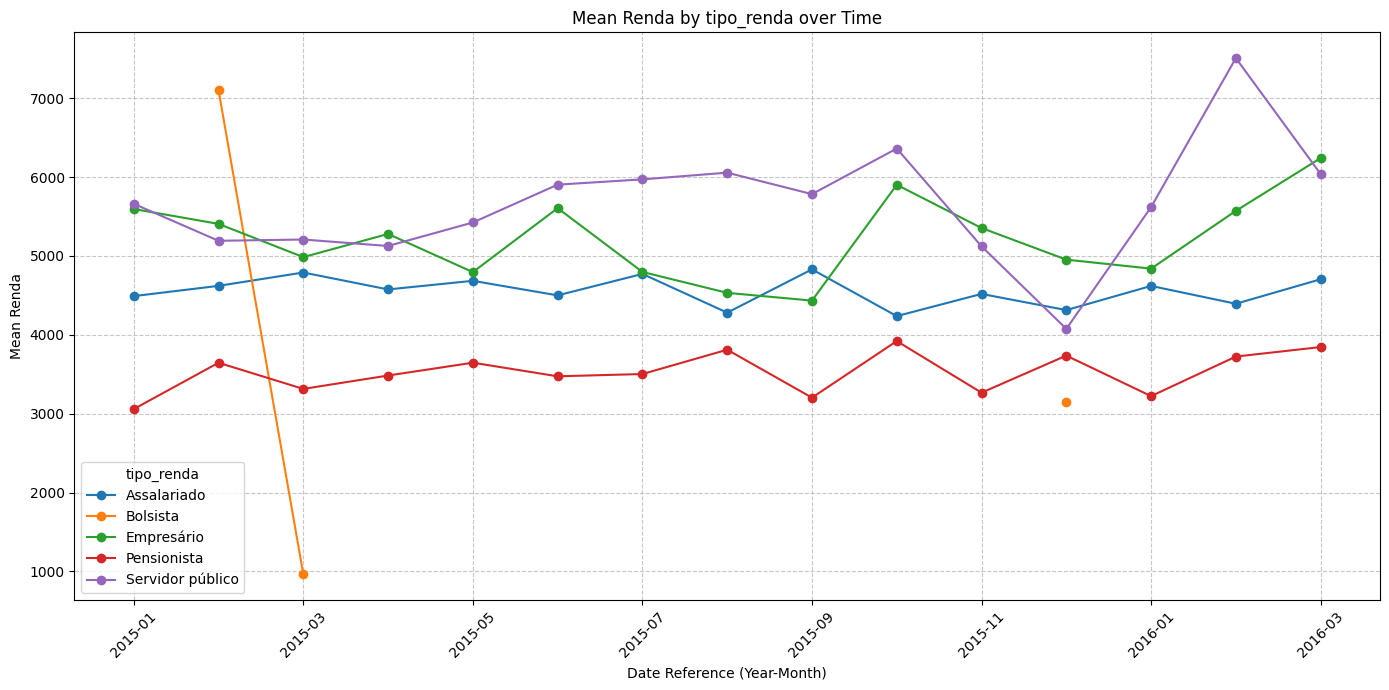

<Figure size 1400x700 with 0 Axes>

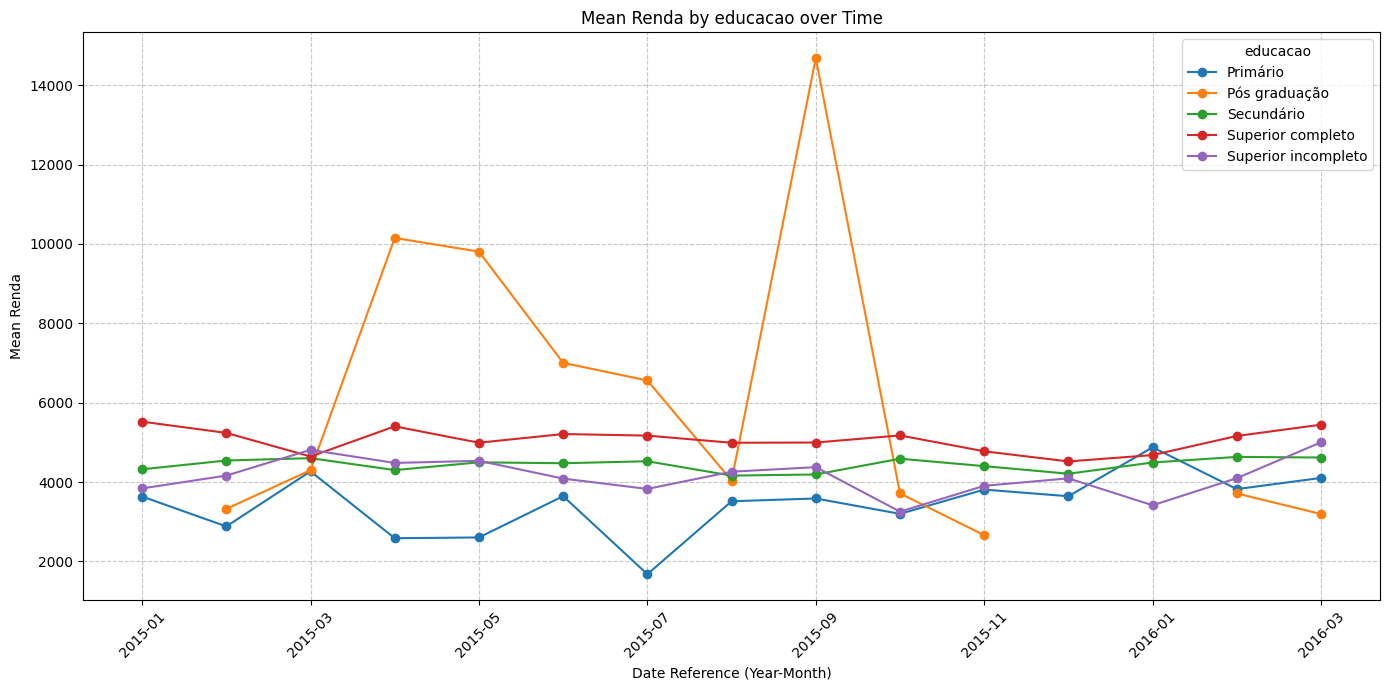

<Figure size 1400x700 with 0 Axes>

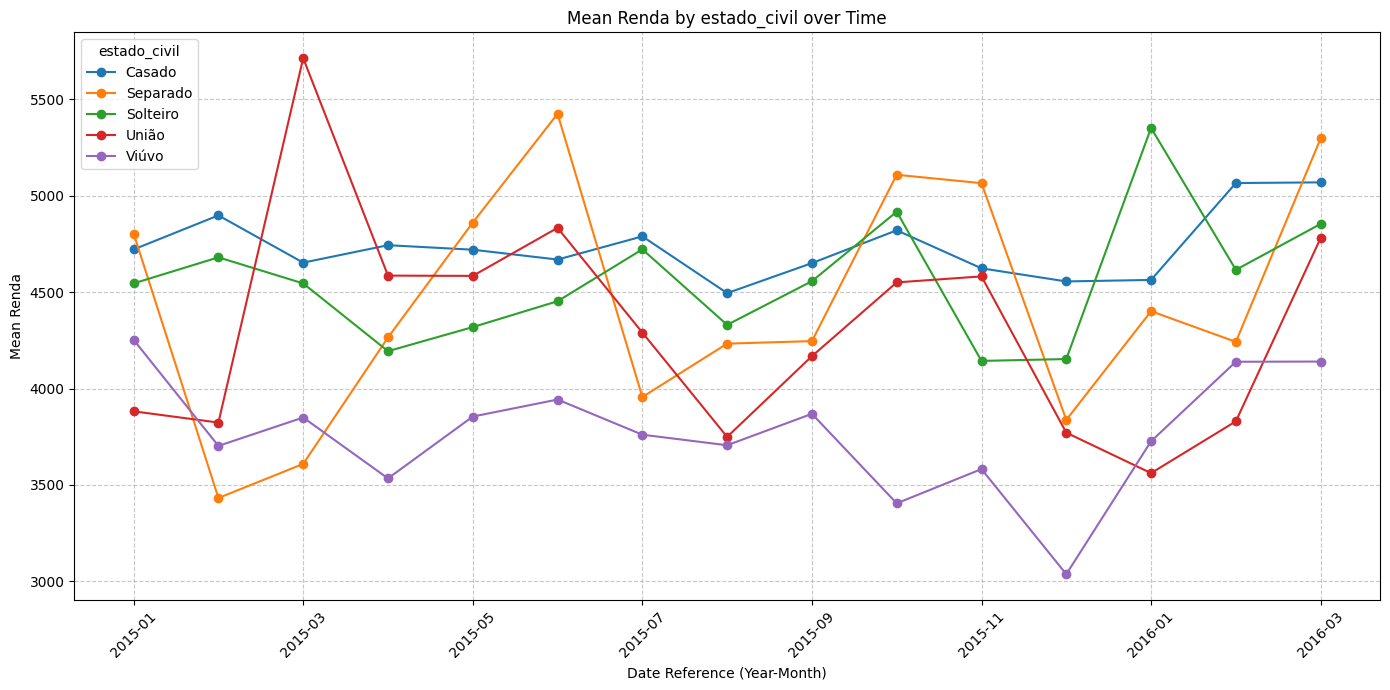

<Figure size 1400x700 with 0 Axes>

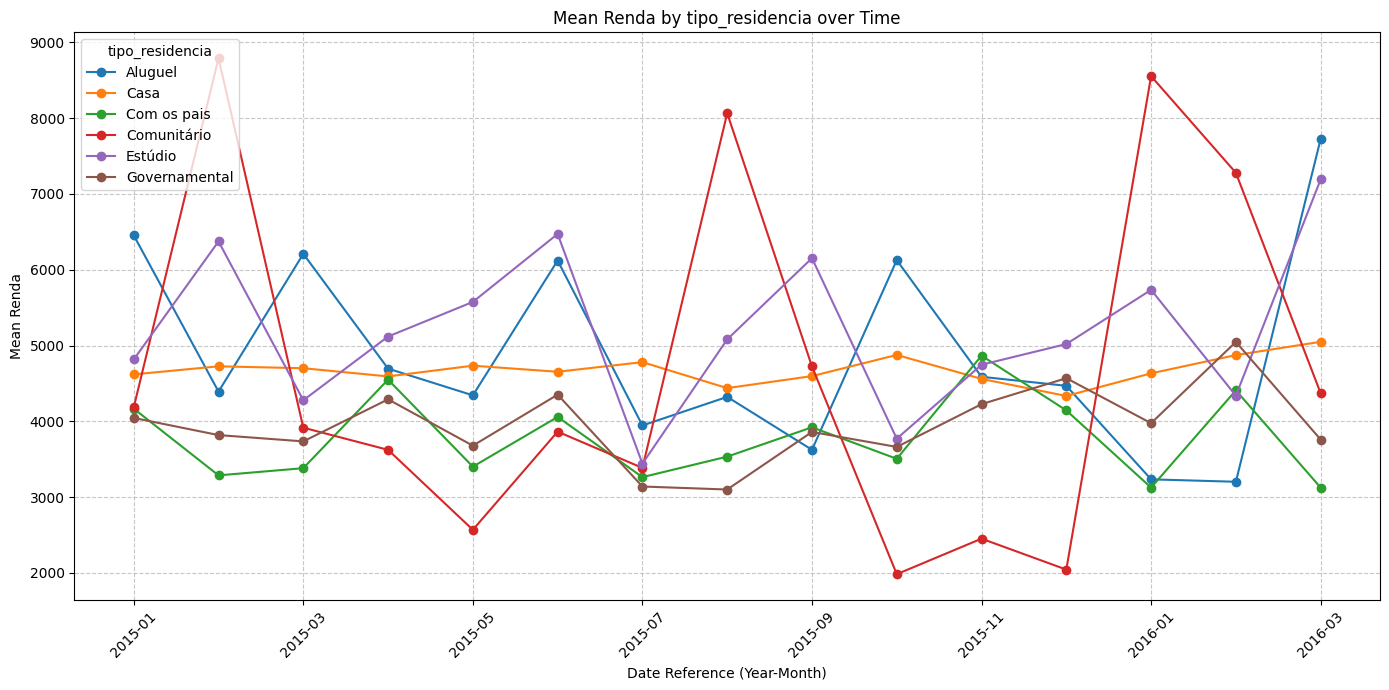

<Figure size 1400x700 with 0 Axes>

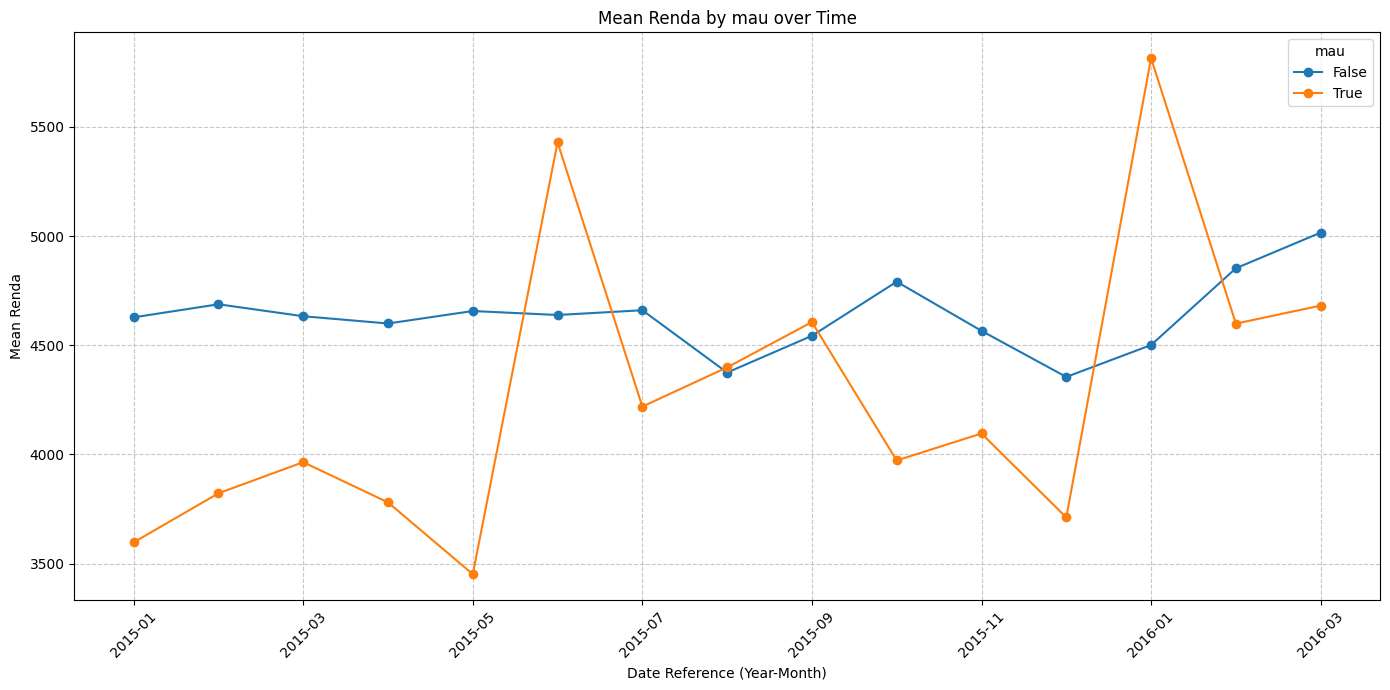

In [9]:
df['data_ref'] = pd.to_datetime(df['data_ref'])
qualitative_cols = df.select_dtypes(include=['object', 'bool']).columns

for col in qualitative_cols:
    plt.figure(figsize=(14, 7))
    # Calculate the mean of 'renda' for each level of the qualitative variable over time
    mean_renda_over_time = df.groupby(['data_ref', col])['renda'].mean().unstack()

    # Format the index to display only month and year
    mean_renda_over_time.index = mean_renda_over_time.index.strftime('%Y-%m')

    mean_renda_over_time.plot(kind='line', marker='o', figsize=(14, 7))
    plt.title(f'Mean Renda by {col} over Time')
    plt.xlabel('Date Reference (Year-Month)')
    plt.ylabel('Mean Renda')
    plt.xticks(rotation=45)
    plt.legend(title=col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [12]:
print("Variance of 'renda' by Qualitative Categories:")

pd.options.display.float_format = '{:.2f}'.format

all_variances = pd.DataFrame()

for col in qualitative_cols:
    variance_by_category = df.groupby(col)['renda'].var().rename(col)
    all_variances = pd.concat([all_variances, variance_by_category], axis=1)

display(all_variances)

pd.reset_option('display.float_format')

Variance of 'renda' by Qualitative Categories:


,sexo,posse_de_veiculo,posse_de_imovel,tipo_renda,educacao,estado_civil,tipo_residencia,mau
F,17846195.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M,26782776.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
False,NaN,20664081.08,20880863.82,NaN,NaN,NaN,NaN,21545480.20
True,NaN,22399616.74,21662199.60,NaN,NaN,NaN,NaN,16425103.63
Assalariado,NaN,NaN,NaN,19618400.50,NaN,NaN,NaN,NaN
Bolsista,NaN,NaN,NaN,9284749.49,NaN,NaN,NaN,NaN
Empresário,NaN,NaN,NaN,29368714.23,NaN,NaN,NaN,NaN
Pensionista,NaN,NaN,NaN,8589847.13,NaN,NaN,NaN,NaN
Servidor público,NaN,NaN,NaN,32728568.20,NaN,NaN,NaN,NaN
Primário,NaN,NaN,NaN,NaN,9223406.99,NaN,NaN,NaN
